# Notebook model HinSAGE cho bài toán Credit Scoring

Notebook này nghiên cứu và áp dụng HinSAGE cho bài toán credit scoring trên graph doanh nghiệp Việt Nam.

Dữ liệu đã được xử lý và build graph ở notebook trước đó (xem `EDA.ipynb` và `build_graph.ipynb`). Ở đây chỉ load lại các file sẵn có: `nodes.csv`, `edges.csv`, `df_processed.pkl`.

Notebook gồm 2 phần:
- Phần 1: Link Prediction (unsupervised pretext task, học embedding từ cấu trúc graph).
- Phần 2: Node Classification (supervised, dùng label active / inactive).

## 1. Setup và Import

Import các thư viện cần thiết. StellarGraph là thư viện chính dùng cho HinSAGE.

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

import stellargraph as sg
from stellargraph.mapper import HinSAGELinkGenerator
from stellargraph.layer import HinSAGE, link_classification
from stellargraph.data import EdgeSplitter

from tensorflow import keras
from tensorflow.keras import layers, optimizers, losses, metrics, Model

In [2]:
print("StellarGraph version:", sg.__version__)
# Yeu cau >= 1.2.0

StellarGraph version: 1.2.1


## 2. Load dữ liệu

Load 3 file đã chuẩn bị từ các notebook trước:
- `nodes.csv`: thông tin của tất cả các node trong graph (Company, Person, Industry, Province, Ward).
- `edges.csv`: các cạnh kết nối.
- `df_processed.pkl`: bảng dữ liệu 1000 công ty đã xử lý, có cột `label` (active / inactive).

In [3]:
nodes_df = pd.read_csv("../data/nodes.csv")
edges_df = pd.read_csv("../data/edges.csv")
df = pd.read_pickle("../data/df_processed.pkl")

print(f"So nodes: {len(nodes_df)}")
print(f"So edges: {len(edges_df)}")
print(f"Phan bo node_type:")
print(nodes_df["node_type"].value_counts())
print(f"\nPhan bo edge_type:")
print(edges_df["edge_type"].value_counts())

So nodes: 2661
So edges: 4369
Phan bo node_type:
node_type
Company     1000
Person       970
Ward         489
Industry     169
Province      33
Name: count, dtype: int64

Phan bo edge_type:
edge_type
DAI_DIEN          1000
TAI_PROVINCE       998
TAI_WARD           998
LINH_VUC           866
THUOC_PROVINCE     507
Name: count, dtype: int64


## 3. Feature Engineering

HinSAGE yêu cầu mỗi node phải có numerical feature vector. Không thể dùng tên chuỗi trực tiếp. Mỗi loại node sẽ có cách tạo feature riêng.

### 3.1 Company features

Mỗi Company sẽ có 4 chiều: `company_age_days`, `is_branch`, `province_enc`, `ward_enc`. Sau đó normalize bằng StandardScaler.

In [4]:
company_nodes = nodes_df[nodes_df["node_type"] == "Company"].copy()

# company_age_days: fill NaN bang median
company_nodes["company_age_days"] = company_nodes["company_age_days"].fillna(
    company_nodes["company_age_days"].median()
)

# is_branch: True/False -> 1/0
company_nodes["is_branch"] = company_nodes["is_branch"].fillna(False).astype(int)

# province_enc: LabelEncoder, fill NaN bang "unknown"
company_nodes["province"] = company_nodes["province"].fillna("unknown")
le_province = LabelEncoder()
company_nodes["province_enc"] = le_province.fit_transform(company_nodes["province"])

# ward_enc: LabelEncoder tren cot ward (dung lam proxy industry, ket hop voi province lam 2 feature dia ly)
company_nodes["ward"] = company_nodes["ward"].fillna("unknown")
le_ward = LabelEncoder()
company_nodes["ward_enc"] = le_ward.fit_transform(company_nodes["ward"])

# Lap feature matrix
company_features = company_nodes[["company_age_days", "is_branch", "province_enc", "ward_enc"]].values.astype(float)

# Normalize
scaler_company = StandardScaler()
company_features_scaled = scaler_company.fit_transform(company_features)

company_features_df = pd.DataFrame(
    company_features_scaled,
    columns=["company_age_days", "is_branch", "province_enc", "ward_enc"],
    index=company_nodes["id"].values,
)
print("Company features shape:", company_features_df.shape)
company_features_df.head()

Company features shape: (1000, 4)


,company_age_days,is_branch,province_enc,ward_enc
COMPANY::0402149708,-0.149992,-0.393363,-0.410811,-0.993462
COMPANY::0317305554,-0.149992,-0.393363,-0.612337,-1.058417
COMPANY::0317300193,-0.149992,-0.393363,-0.612337,0.154064
COMPANY::3703060512,-0.149992,-0.393363,-0.612337,1.352111
COMPANY::3703060840,-0.149992,-0.393363,-0.612337,-1.303800


### 3.2 Person features

Mỗi Person có 1 feature `degree` = số công ty mà người đó đại diện (số cạnh DAI_DIEN mà Person đó là đầu của cạnh).

In [5]:
person_nodes = nodes_df[nodes_df["node_type"] == "Person"].copy()

# Dem degree: so canh DAI_DIEN co target la Person
dai_dien_edges = edges_df[edges_df["edge_type"] == "DAI_DIEN"]
person_degree = dai_dien_edges["target"].value_counts()

person_nodes["degree"] = person_nodes["id"].map(person_degree).fillna(0).astype(float)

scaler_person = StandardScaler()
person_features_scaled = scaler_person.fit_transform(person_nodes[["degree"]].values)

person_features_df = pd.DataFrame(
    person_features_scaled,
    columns=["degree"],
    index=person_nodes["id"].values,
)
print("Person features shape:", person_features_df.shape)
person_features_df.head()

Person features shape: (970, 1)


,degree
PERSON::NGUYỄN XUÂN HIẾU,-0.10972
PERSON::Y - THƯƠNG NIÊ,-0.10972
PERSON::TRẦN VĂN TRIỀU,-0.10972
PERSON::NGUYỄN VĂN ĐÔNG,-0.10972
PERSON::HOÀNG VĂN MẠNH,6.98552


### 3.3 Industry, Province, Ward features

3 loại này không có attribute thực. Nếu dùng LabelEncoder + chia max sẽ tạo ra 1 con số ordinal vô nghĩa (ngầm hiểu "ngành 7 > ngành 3" trong khi không có thứ tự nào cả). Với 1 chiều feature, HinSAGE gần như không học được gì từ các node này.

Standard practice khi node không có attribute thực: **random initialization** (8 chiều). HinSAGE sẽ tự cập nhật các vector này qua backpropagation lúc train.

In [6]:
def make_random_features(node_type, dim=8, seed=42):
    """
    Tao random feature cho cac node khong co attribute thuc.
    HinSAGE se hoc cap nhat cac vector nay qua backpropagation.
    dim=8 du de mang thong tin, khong qua lon so voi graph nho.
    """
    sub  = nodes_df[nodes_df["node_type"] == node_type]
    rng  = np.random.RandomState(seed)
    feats = rng.normal(0, 0.1, size=(len(sub), dim))
    return pd.DataFrame(
        feats,
        index=sub["id"].values,
        columns=[f"f{i}" for i in range(dim)],
    )

industry_features_df = make_random_features("Industry", dim=8)
province_features_df = make_random_features("Province", dim=8)
ward_features_df     = make_random_features("Ward",     dim=8)

print("Industry features shape:", industry_features_df.shape)
print("Province features shape:", province_features_df.shape)
print("Ward features shape:    ", ward_features_df.shape)

Industry features shape: (169, 8)
Province features shape: (33, 8)
Ward features shape:     (489, 8)


### 3.4 Kiểm tra lại các feature DataFrame

In ra shape để chắc chắn mỗi loại node đều có feature đầy đủ.

In [7]:
for name, fdf in [
    ("Company",  company_features_df),
    ("Person",   person_features_df),
    ("Industry", industry_features_df),
    ("Province", province_features_df),
    ("Ward",     ward_features_df),
]:
    print(f"{name:9s}: {fdf.shape}, index sample: {list(fdf.index[:2])}")

Company  : (1000, 4), index sample: ['COMPANY::0402149708', 'COMPANY::0317305554']
Person   : (970, 1), index sample: ['PERSON::NGUYỄN XUÂN HIẾU', 'PERSON::Y - THƯƠNG NIÊ']
Industry : (169, 8), index sample: ['INDUSTRY::điều hành tua du lịch', 'INDUSTRY::bán lẻ hình thức khác chưa được phân vào đâu']
Province : (33, 8), index sample: ['PROVINCE::Thành phố Đà Nẵng', 'PROVINCE::Thành phố Hồ Chí Minh']
Ward     : (489, 8), index sample: ['WARD::Phường Hải Châu', 'WARD::Phường Gò Vấp']


## 4. Lọc edges cho Link Prediction

Chỉ giữ lại 2 loại edge: `DAI_DIEN` và `LINH_VUC`.

Lý do: Province và Ward là "super hub" — chúng kết nối rất nhiều công ty qua vị trí địa lý. Nếu dùng các edge này làm training signal cho link prediction, model sẽ học rằng mọi công ty đều "gần" với nhau, không có ý nghĩa. Edge DAI_DIEN và LINH_VUC mới phản ánh quan hệ thực sự.

In [8]:
edges_for_lp = edges_df[edges_df["edge_type"].isin(["DAI_DIEN", "LINH_VUC"])].copy()
print(f"So edges dung cho link prediction: {len(edges_for_lp)}")
print(edges_for_lp["edge_type"].value_counts())

So edges dung cho link prediction: 1866
edge_type
DAI_DIEN    1000
LINH_VUC     866
Name: count, dtype: int64


## 5. Tạo StellarGraph object

StellarGraph là thư viện chuyên cho machine learning trên graph. Tạo heterogeneous graph với 5 loại node và đầy đủ feature vector.

In [9]:
G = sg.StellarGraph(
    nodes={
        "Company":  company_features_df,
        "Person":   person_features_df,
        "Industry": industry_features_df,
        "Province": province_features_df,
        "Ward":     ward_features_df,
    },
    edges=edges_for_lp,
    source_column="source",
    target_column="target",
    edge_type_column="edge_type",
)
print(G.info())

StellarGraph: Undirected multigraph
 Nodes: 2661, Edges: 1866

 Node types:
  Company: [1000]
    Features: float32 vector, length 4
    Edge types: Company-DAI_DIEN->Person, Company-LINH_VUC->Industry
  Person: [970]
    Features: float32 vector, length 1
    Edge types: Person-DAI_DIEN->Company
  Ward: [489]
    Features: float32 vector, length 8
    Edge types: none
  Industry: [169]
    Features: float32 vector, length 8
    Edge types: Industry-LINH_VUC->Company
  Province: [33]
    Features: float32 vector, length 8
    Edge types: none

 Edge types:
    Company-DAI_DIEN->Person: [1000]
        Weights: all 1 (default)
        Features: none
    Company-LINH_VUC->Industry: [866]
        Weights: all 1 (default)
        Features: none


## 6. Tách train / test edges

`EdgeSplitter` chia các edge LINH_VUC thành train và test, đồng thời tự động tạo các negative edges (cặp node không có edge thật sự) làm mẫu âm. Đây là cách chuẩn bị data cho bài toán phân loại nhị phân: edge này có thật hay không.

In [10]:
edge_splitter_test = EdgeSplitter(G)
G_test, edges_test, labels_test = edge_splitter_test.train_test_split(
    p=0.1,
    method="global",
    edge_label="LINH_VUC",
)

edge_splitter_train = EdgeSplitter(G_test)
G_train, edges_train, labels_train = edge_splitter_train.train_test_split(
    p=0.1,
    method="global",
    edge_label="LINH_VUC",
)

# Luu y: EdgeSplitter coi graph la undirected nen mot so edge bi dao chieu thanh (Industry, Company).
# Ngoai ra negative edges co the la cap node bat ky. Phai filter + normalize ve dang (Company, Industry).
def filter_normalize_edges(edges, labels):
    edges = np.asarray(edges)
    labels = np.asarray(labels)
    keep = []
    out_edges = []
    for i, (a, b) in enumerate(edges):
        a_c, b_c = a.startswith("COMPANY::"), b.startswith("COMPANY::")
        a_i, b_i = a.startswith("INDUSTRY::"), b.startswith("INDUSTRY::")
        if a_c and b_i:
            out_edges.append([a, b]); keep.append(i)
        elif a_i and b_c:
            out_edges.append([b, a]); keep.append(i)
    return np.array(out_edges), labels[keep]

edges_train, labels_train = filter_normalize_edges(edges_train, labels_train)
edges_test,  labels_test  = filter_normalize_edges(edges_test,  labels_test)

print(f"Train: {len(edges_train)} edges, Test: {len(edges_test)} edges")
print(f"Label phan bo train: {pd.Series(labels_train).value_counts().to_dict()}")

Network has 866 edges of type LINH_VUC
Network has 866 edges of type LINH_VUC
** Sampled 86 positive and 86 negative edges. **
Network has 780 edges of type LINH_VUC
Network has 780 edges of type LINH_VUC
** Sampled 78 positive and 78 negative edges. **
Train: 156 edges, Test: 172 edges
Label phan bo train: {1: 78, 0: 78}


## 7. Generator và khai báo Model

`HinSAGELinkGenerator` sẽ sample các node láng giềng quanh từng edge để tạo input cho model. `num_samples = [8, 4]` nghĩa là hop 1 lấy 8 láng giềng, hop 2 lấy 4 láng giềng.

In [11]:
batch_size = 20
num_samples = [8, 4]

# LINH_VUC noi Company <-> Industry nen head_node_types phai khop voi cap (Company, Industry).
# Edge cua chung ta da duoc normalize de Company luon o vi tri 0.
train_gen = HinSAGELinkGenerator(
    G_train, batch_size, num_samples,
    head_node_types=["Company", "Industry"],
)
train_flow = train_gen.flow(edges_train, labels_train, shuffle=True)

test_gen = HinSAGELinkGenerator(
    G_test, batch_size, num_samples,
    head_node_types=["Company", "Industry"],
)
test_flow = test_gen.flow(edges_test, labels_test)

Kiến trúc model: HinSAGE tạo embedding cho mỗi Company node bằng cách aggregate thông tin từ hàng xóm, qua 2 lớp với kích thước embedding lần lượt là 32 và 32. Sau đó lấy embedding của 2 Company trong mỗi cặp edge, kết hợp bằng inner product rồi qua 1 lớp phân loại binary.

In [12]:
hinsage_layer_sizes = [32, 32]

hinsage = HinSAGE(
    layer_sizes=hinsage_layer_sizes,
    generator=train_gen,
    bias=True,
    dropout=0.3,
)

x_inp, x_out = hinsage.in_out_tensors()

prediction = link_classification(
    output_dim=1,
    output_act="relu",
    edge_embedding_method="ip",
)(x_out)

model = Model(inputs=x_inp, outputs=prediction)
# Note: dung learning_rate= thay vi lr= (lr deprecated tu Keras 2.11)
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss=losses.binary_crossentropy,
    metrics=["acc", metrics.AUC(name="auc")],
)
model.summary()

link_classification: using 'ip' method to combine node embeddings into edge embeddings
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 8, 1)]               0         []                            
                                                                                                  
 input_4 (InputLayer)        [(None, 8, 8)]               0         []                            
                                                                                                  
 input_6 (InputLayer)        [(None, 32, 4)]              0         []                            
                                                                                                  
 input_7 (InputLayer)        [(None, 32, 4)]              0         []                            
       

## 8. Train model

Với 1000 node thì train khá nhanh, 20 epochs là đủ. Theo dõi val loss / val AUC để biết khi nào nên dừng.

In [13]:
history = model.fit(
    train_flow,
    epochs=20,
    validation_data=test_flow,
    verbose=1,
)

Epoch 1/20
8/8 [==============================] - 13s 294ms/step - loss: 5.3581 - acc: 0.4936 - auc: 0.5131 - val_loss: 4.9685 - val_acc: 0.4942 - val_auc: 0.4927
Epoch 2/20
8/8 [==============================] - 1s 68ms/step - loss: 4.3514 - acc: 0.5064 - auc: 0.4857 - val_loss: 3.8332 - val_acc: 0.4826 - val_auc: 0.4904
Epoch 3/20
8/8 [==============================] - 1s 58ms/step - loss: 2.7148 - acc: 0.4872 - auc: 0.5995 - val_loss: 2.6213 - val_acc: 0.5116 - val_auc: 0.5548
Epoch 4/20
8/8 [==============================] - 1s 56ms/step - loss: 3.0230 - acc: 0.5000 - auc: 0.4592 - val_loss: 1.9175 - val_acc: 0.5349 - val_auc: 0.5716
Epoch 5/20
8/8 [==============================] - 0s 55ms/step - loss: 2.0498 - acc: 0.5064 - auc: 0.5763 - val_loss: 1.5884 - val_acc: 0.5698 - val_auc: 0.5898
Epoch 6/20
8/8 [==============================] - 0s 31ms/step - loss: 1.4935 - acc: 0.5128 - auc: 0.5461 - val_loss: 1.4127 - val_acc: 0.5756 - val_auc: 0.6006
Epoch 7/20
8/8 [================

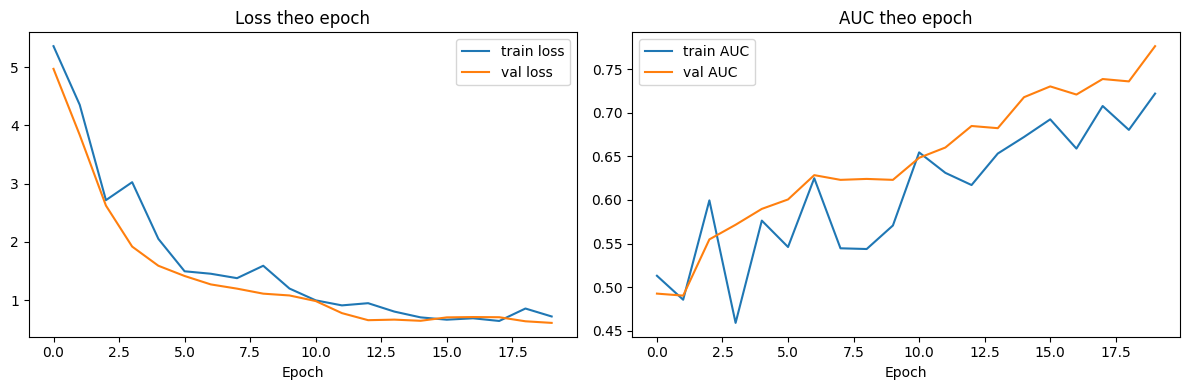

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"], label="train loss")
axes[0].plot(history.history["val_loss"], label="val loss")
axes[0].set_title("Loss theo epoch")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["auc"], label="train AUC")
axes[1].plot(history.history["val_auc"], label="val AUC")
axes[1].set_title("AUC theo epoch")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig("../photo/link_prediction_training.png", dpi=100)
plt.show()

## 9. Lấy embedding từ model đã train

Model được train trên cặp (Company, Industry) nên `x_inp` / `x_out` có shape dành cho cặp node. Phải feed cặp (Company, Industry) chứ không dùng trực tiếp với `HinSAGENodeGenerator` được.

**Cách làm (đã fix bias):** ghép mỗi Company với **chính industry thực tế của nó** (lấy từ edge LINH_VUC). Công ty không có LINH_VUC (chi nhánh) thì dùng industry phổ biến nhất làm fallback. Sau đó chỉ giữ lại output bên Company (`x_out[0]`) làm embedding.

Trước đây em ghép tất cả công ty với cùng 1 dummy Industry — làm mọi embedding bị tính trong cùng context, mất đi signal ngành nghề (là thứ quan trọng nhất mà Link Prediction cần học).

In [15]:
# Mapping: company_id -> industry_id thuc te (lay tu edge LINH_VUC)
linh_vuc_map = (
    edges_df[edges_df["edge_type"] == "LINH_VUC"]
    .set_index("source")["target"]
    .to_dict()
)

# Fallback cho cong ty khong co LINH_VUC (cac chi nhanh): dung industry pho bien nhat
fallback_industry = (
    edges_df[edges_df["edge_type"] == "LINH_VUC"]["target"]
    .value_counts()
    .index[0]
)

company_ids = [n for n in G.nodes() if n.startswith("COMPANY::")]
pair_ids = np.array([
    [cid, linh_vuc_map.get(cid, fallback_industry)]
    for cid in company_ids
])

emb_gen = HinSAGELinkGenerator(
    G, batch_size=50, num_samples=num_samples,
    head_node_types=["Company", "Industry"],
)
# Pass dummy labels de Keras unpack duoc input tuple cua hetero generator.
dummy_labels = np.zeros(len(pair_ids))
emb_flow = emb_gen.flow(pair_ids, dummy_labels)

# Lay rieng output ben Company (x_out[0]) lam embedding
embedding_model = Model(inputs=x_inp, outputs=x_out[0])
embeddings = embedding_model.predict(emb_flow)
print(f"Shape cua embedding matrix: {embeddings.shape}")
print(f"Dung industry thuc te: {sum(1 for c in company_ids if c in linh_vuc_map)}/1000")
print(f"Dung fallback        : {sum(1 for c in company_ids if c not in linh_vuc_map)}/1000")

20/20 [==============================] - 2s 48ms/step
Shape cua embedding matrix: (1000, 32)
Dung industry thuc te: 866/1000
Dung fallback        : 134/1000


Nếu cell trên báo lỗi do `x_inp` / `x_out` không tương thích với NodeGenerator, dùng phương án dự phòng: build lại HinSAGE với NodeGenerator.

In [16]:
# Phuong an du phong - chi chay neu cell tren bi loi
# node_gen_emb = HinSAGENodeGenerator(G, batch_size=50, num_samples=num_samples, head_node_types=["Company"])
# hinsage_emb = HinSAGE(layer_sizes=hinsage_layer_sizes, generator=node_gen_emb, bias=True, dropout=0.3)
# x_inp_node, x_out_node = hinsage_emb.in_out_tensors()
# embedding_model_v2 = Model(inputs=x_inp_node, outputs=x_out_node)
# embeddings = embedding_model_v2.predict(node_gen_emb.flow(company_ids))
# print(embeddings.shape)

## 10. Lưu embedding và Visualize

Lưu embedding vào CSV cho các bước sau. Visualize bằng t-SNE để kiểm tra chất lượng embedding: công ty cùng ngành / cùng khu vực nên nằm gần nhau, 6 công ty inactive nên có xu hướng tách ra.

In [17]:
tax_codes = [nid.replace("COMPANY::", "") for nid in company_ids]
emb_cols = [f"emb_{i}" for i in range(embeddings.shape[1])]
emb_df = pd.DataFrame(embeddings, columns=emb_cols)
emb_df.insert(0, "tax_code", tax_codes)
emb_df.insert(1, "node_id", company_ids)
emb_df.to_csv("../data/company_embeddings_lp.csv", index=False)
print(f"Da luu: company_embeddings_lp.csv ({len(emb_df)} rows, {len(emb_cols)} embedding dims)")

Da luu: company_embeddings_lp.csv (1000 rows, 32 embedding dims)


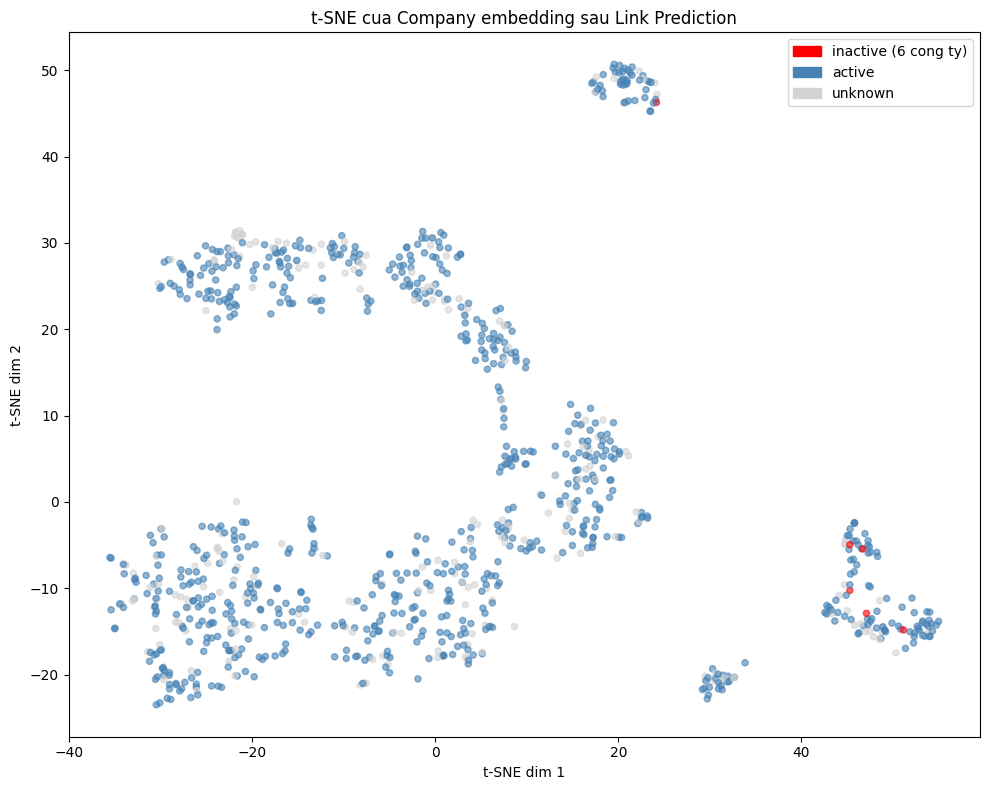

In [18]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
emb_2d = tsne.fit_transform(embeddings)

company_node_df = nodes_df[nodes_df["node_type"] == "Company"].copy()
company_node_df = company_node_df.set_index("id")

colors = []
for nid in company_ids:
    status = company_node_df.loc[nid, "status"] if nid in company_node_df.index else "unknown"
    if status == "inactive":
        colors.append("red")
    elif status == "active":
        colors.append("steelblue")
    else:
        colors.append("lightgray")

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(emb_2d[:, 0], emb_2d[:, 1], c=colors, alpha=0.6, s=20)

patches = [
    mpatches.Patch(color="red",       label="inactive (6 cong ty)"),
    mpatches.Patch(color="steelblue", label="active"),
    mpatches.Patch(color="lightgray", label="unknown"),
]
ax.legend(handles=patches, loc="upper right")
ax.set_title("t-SNE cua Company embedding sau Link Prediction")
ax.set_xlabel("t-SNE dim 1")
ax.set_ylabel("t-SNE dim 2")
plt.tight_layout()
plt.savefig("../photo/embedding_tsne_lp.png", dpi=100)
plt.show()

Nhận xét: quan sát trong biểu đồ, nếu các điểm đỏ (inactive) nằm tách biệt hoặc ở rìa biên của cluster thì là tín hiệu tốt — chứng tỏ embedding bắt được khác biệt về cấu trúc giữa công ty inactive và active. Nếu chúng nằm lẫn vào đám điểm xanh thì có thể do sample quá ít (chỉ 6 inactive / 1000), chưa đủ để kết luận.

---

# Phần 2: Node Classification với HinSAGE

Đến đây xong Phần 1. Tiếp theo là Phần 2 — dùng graph + node features để phân loại Company: active hay inactive.

Đây là supervised learning, cần dùng label thực sự. Model sau khi train có thể extract embedding để dùng như một credit score feature.

## 11. Chuẩn bị label

Trong data thực tế, label "risky" mà spec nói đến thực ra được lưu dưới tên **"inactive"** trong cột `df["label"]`. Phân bố: 778 active, 6 inactive, 216 unknown. Bỏ 216 unknown, chỉ giữ lại 784 công ty có label rõ ràng.

Mất cân bằng nghiêm trọng: 6 inactive / 778 active ≈ 0.77%. Sẽ xử lý bằng `class_weight`.

In [19]:
df_labeled = df[df["label"].isin(["active", "inactive"])].copy()
df_labeled["label_bin"] = (df_labeled["label"] == "inactive").astype(int)

print(f"Tong so: {len(df_labeled)}")
print(f"Active:   {(df_labeled['label_bin']==0).sum()}")
print(f"Inactive: {(df_labeled['label_bin']==1).sum()}")

n_active   = (df_labeled["label_bin"] == 0).sum()
n_inactive = (df_labeled["label_bin"] == 1).sum()
class_weight = {0: 1, 1: int(n_active / n_inactive)}
print(f"\nClass weight se dung: {class_weight}")

Tong so: 784
Active:   778
Inactive: 6

Class weight se dung: {0: 1, 1: 129}


## 12. Tạo StellarGraph cho Node Classification

Khác với Phần 1 (chỉ dùng 2 loại edge), lần này dùng **toàn bộ 5 loại edge** kể cả TAI_PROVINCE, TAI_WARD, THUOC_PROVINCE. Lý do: mục tiêu là phân loại node, không phải học từ signal của edge nên việc có thêm thông tin địa lý chỉ giúp model phân loại tốt hơn.

In [20]:
G_full = sg.StellarGraph(
    nodes={
        "Company":  company_features_df,
        "Person":   person_features_df,
        "Industry": industry_features_df,
        "Province": province_features_df,
        "Ward":     ward_features_df,
    },
    edges=edges_df,
    source_column="source",
    target_column="target",
    edge_type_column="edge_type",
)
print(G_full.info())

StellarGraph: Undirected multigraph
 Nodes: 2661, Edges: 4369

 Node types:
  Company: [1000]
    Features: float32 vector, length 4
    Edge types: Company-DAI_DIEN->Person, Company-LINH_VUC->Industry, Company-TAI_PROVINCE->Province, Company-TAI_WARD->Ward
  Person: [970]
    Features: float32 vector, length 1
    Edge types: Person-DAI_DIEN->Company
  Ward: [489]
    Features: float32 vector, length 8
    Edge types: Ward-TAI_WARD->Company, Ward-THUOC_PROVINCE->Province
  Industry: [169]
    Features: float32 vector, length 8
    Edge types: Industry-LINH_VUC->Company
  Province: [33]
    Features: float32 vector, length 8
    Edge types: Province-TAI_PROVINCE->Company, Province-THUOC_PROVINCE->Ward

 Edge types:
    Company-DAI_DIEN->Person: [1000]
        Weights: all 1 (default)
        Features: none
    Company-TAI_WARD->Ward: [998]
        Weights: all 1 (default)
        Features: none
    Company-TAI_PROVINCE->Province: [998]
        Weights: all 1 (default)
        Features:

## 13. Tách train / test set cho Node Classification

Tách 80 / 20. Vì chỉ có 6 inactive, dùng `stratify` để đảm bảo cả 2 tập đều có inactive.

In [21]:
from sklearn.model_selection import train_test_split

labeled_node_ids = ["COMPANY::" + str(tc) for tc in df_labeled["tax_code"]]
labeled_labels   = df_labeled["label_bin"].values

valid_mask = [nid in G_full.nodes() for nid in labeled_node_ids]
labeled_node_ids = [nid for nid, m in zip(labeled_node_ids, valid_mask) if m]
labeled_labels   = labeled_labels[valid_mask]
print(f"Node co the dung: {len(labeled_node_ids)}")

train_ids, test_ids, train_labels, test_labels = train_test_split(
    labeled_node_ids,
    labeled_labels,
    test_size=0.2,
    stratify=labeled_labels,
    random_state=42,
)
print(f"Train: {len(train_ids)} nodes | Test: {len(test_ids)} nodes")
print(f"Risky trong train: {sum(train_labels)} | Test: {sum(test_labels)}")

Node co the dung: 784
Train: 627 nodes | Test: 157 nodes
Risky trong train: 5 | Test: 1


## 14. Generator và Model cho Node Classification

`HinSAGENodeGenerator` sample các láng giềng của mỗi Company node. Kiến trúc model tương tự Phần 1 nhưng đầu ra là 1 sigmoid cho phân loại nhị phân.

In [22]:
from stellargraph.mapper import HinSAGENodeGenerator
from stellargraph.layer import HinSAGE

batch_size_nc = 20
num_samples_nc = [8, 4]

# HinSAGENodeGenerator dung tham so head_node_type (so it), khac voi LinkGenerator dung head_node_types (so nhieu).
node_gen = HinSAGENodeGenerator(G_full, batch_size_nc, num_samples_nc, head_node_type="Company")
train_flow_nc = node_gen.flow(train_ids, train_labels, shuffle=True)
test_flow_nc  = node_gen.flow(test_ids, test_labels)

hinsage_nc = HinSAGE(
    layer_sizes=[32, 32],
    generator=node_gen,
    bias=True,
    dropout=0.3,
)

x_inp_nc, x_out_nc = hinsage_nc.in_out_tensors()

output = layers.Dense(1, activation="sigmoid")(x_out_nc)

model_nc = Model(inputs=x_inp_nc, outputs=output)
# Note: learning_rate= (lr deprecated tu Keras 2.11)
model_nc.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss=losses.binary_crossentropy,
    metrics=["acc", metrics.AUC(name="auc"), metrics.Precision(name="precision"), metrics.Recall(name="recall")],
)
model_nc.summary()

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_15 (InputLayer)       [(None, 32, 4)]              0         []                            
                                                                                                  
 input_16 (InputLayer)       [(None, 32, 4)]              0         []                            
                                                                                                  
 input_17 (InputLayer)       [(None, 32, 4)]              0         []                            
                                                                                                  
 input_18 (InputLayer)       [(None, 32, 8)]              0         []                            
                                                                                            

## 15. Train Node Classification

Train với `class_weight` để bù mất cân bằng. Tập nhỏ nên 30 epochs là đủ.

In [23]:
history_nc = model_nc.fit(
    train_flow_nc,
    epochs=30,
    validation_data=test_flow_nc,
    class_weight=class_weight,
    verbose=1,
)

Epoch 1/30
32/32 [==============================] - 8s 50ms/step - loss: 1.4342 - acc: 0.9474 - auc: 0.4979 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_loss: 0.5131 - val_acc: 0.9936 - val_auc: 0.6795 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/30
32/32 [==============================] - 1s 21ms/step - loss: 1.3280 - acc: 0.9904 - auc: 0.8344 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_loss: 0.4367 - val_acc: 0.9936 - val_auc: 0.8301 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/30
32/32 [==============================] - 1s 18ms/step - loss: 1.2599 - acc: 0.9856 - auc: 0.8899 - precision: 0.1667 - recall: 0.2000 - val_loss: 0.4157 - val_acc: 0.9809 - val_auc: 0.8494 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/30
32/32 [==============================] - 1s 20ms/step - loss: 1.1919 - acc: 0.9713 - auc: 0.9193 - precision: 0.1176 - recall: 0.4000 - val_loss: 0.4035 - val_acc: 0.9554 - val_auc: 0.8654 - val_precision: 0.0000e+

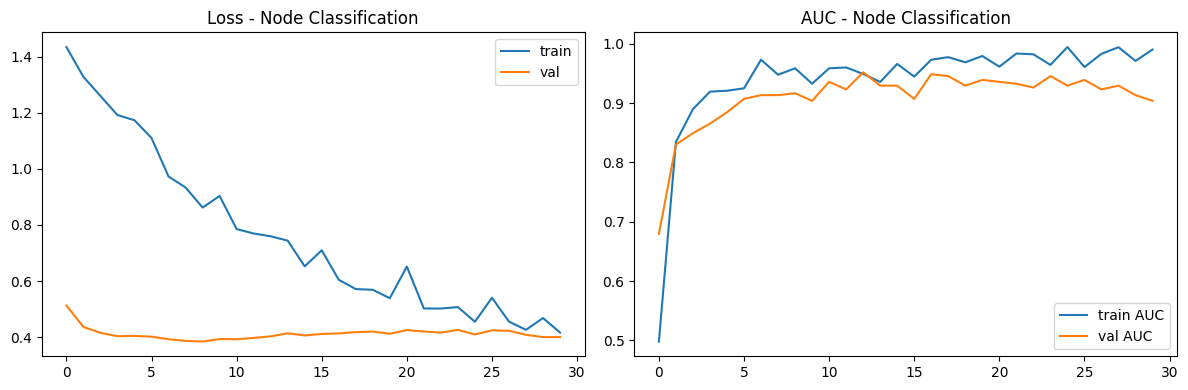

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_nc.history["loss"], label="train")
axes[0].plot(history_nc.history["val_loss"], label="val")
axes[0].set_title("Loss - Node Classification")
axes[0].legend()

axes[1].plot(history_nc.history["auc"], label="train AUC")
axes[1].plot(history_nc.history["val_auc"], label="val AUC")
axes[1].set_title("AUC - Node Classification")
axes[1].legend()

plt.tight_layout()
plt.savefig("../photo/node_classification_training.png", dpi=100)
plt.show()

## 16. Đánh giá model

Đo lường bằng AUC-ROC, Precision, Recall, Confusion matrix trên **riêng tập test** (không dùng `labeled_node_ids` như cũ — sẽ bị data leakage vì model đã học từ `train_ids`).

**Không dùng Accuracy** — với dữ liệu mất cân bằng 130:1, model dù chỉ predict toàn active cũng đạt 99% accuracy nhưng vô dụng.

Cuối cell có thêm threshold sweep: vì model train với `class_weight=129` nên output probability bị lệch, threshold 0.5 mặc định có thể không tối ưu.

8/8 [==============================] - 1s 13ms/step
=== Classification Report (test set) ===
              precision    recall  f1-score   support

      active       1.00      0.83      0.91       156
    inactive       0.04      1.00      0.07         1

    accuracy                           0.83       157
   macro avg       0.52      0.92      0.49       157
weighted avg       0.99      0.83      0.90       157

AUC-ROC: 0.9103

=== Confusion Matrix ===


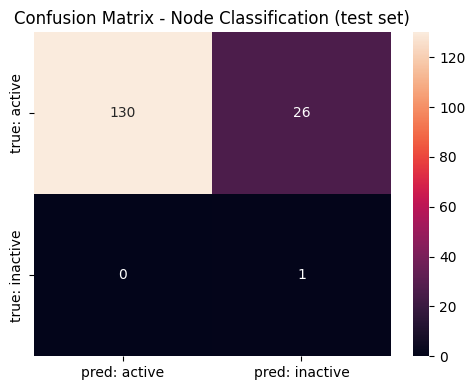


=== Thu cac threshold ===
  threshold=0.1 | TP=1 FP=37 FN=0 | Precision=0.03 Recall=1.00
  threshold=0.2 | TP=1 FP=28 FN=0 | Precision=0.03 Recall=1.00
  threshold=0.3 | TP=1 FP=27 FN=0 | Precision=0.04 Recall=1.00
  threshold=0.4 | TP=1 FP=27 FN=0 | Precision=0.04 Recall=1.00
  threshold=0.5 | TP=1 FP=26 FN=0 | Precision=0.04 Recall=1.00


In [25]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns

# Chi evaluate tren test_ids/test_labels (da tach o Section 13), khong dung labeled_node_ids
# vi se bi data leakage - model da hoc tren train_ids roi.
test_flow_eval = node_gen.flow(test_ids, test_labels)
y_pred_proba   = model_nc.predict(test_flow_eval).flatten()
y_pred         = (y_pred_proba >= 0.5).astype(int)

print("=== Classification Report (test set) ===")
print(classification_report(test_labels, y_pred, target_names=["active", "inactive"]))

print(f"AUC-ROC: {roc_auc_score(test_labels, y_pred_proba):.4f}")

print("\n=== Confusion Matrix ===")
cm = confusion_matrix(test_labels, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", ax=ax,
            xticklabels=["pred: active", "pred: inactive"],
            yticklabels=["true: active", "true: inactive"])
ax.set_title("Confusion Matrix - Node Classification (test set)")
plt.tight_layout()
plt.savefig("../photo/confusion_matrix_nc.png", dpi=100)
plt.show()

# Threshold sweep: model train voi class_weight=129 nen probability bi lech.
# 0.5 mac dinh co the khong toi uu - thu cac nguong khac.
print("\n=== Thu cac threshold ===")
for thresh in [0.1, 0.2, 0.3, 0.4, 0.5]:
    y_t  = (y_pred_proba >= thresh).astype(int)
    tp   = ((y_t == 1) & (test_labels == 1)).sum()
    fp   = ((y_t == 1) & (test_labels == 0)).sum()
    fn   = ((y_t == 0) & (test_labels == 1)).sum()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    print(f"  threshold={thresh:.1f} | TP={tp} FP={fp} FN={fn} | Precision={prec:.2f} Recall={rec:.2f}")

# Ghi chu: test set chi co 1 inactive (vi stratified 80/20 tren 6 inactive),
# nen cac con so nay chi mang tinh tham khao, khong co y nghia thong ke.

## 17. Lấy embedding từ Node Classification model

Tương tự Phần 1, lấy embedding của tất cả Company node từ lớp trước softmax. Lần này embedding có thêm supervised signal nên về mặt lý thuyết công ty inactive sẽ được tách biệt hơn.

In [26]:
embedding_model_nc = Model(inputs=x_inp_nc, outputs=x_out_nc)

all_company_ids_nc = [n for n in G_full.nodes() if n.startswith("COMPANY::")]
# Pass dummy labels de Keras unpack duoc format input (tuong tu Section 9).
all_flow_nc = node_gen.flow(all_company_ids_nc, np.zeros(len(all_company_ids_nc)))
embeddings_nc = embedding_model_nc.predict(all_flow_nc)
print(f"Shape embedding: {embeddings_nc.shape}")

tax_codes_nc = [nid.replace("COMPANY::", "") for nid in all_company_ids_nc]
emb_cols_nc  = [f"emb_{i}" for i in range(embeddings_nc.shape[1])]
emb_nc_df = pd.DataFrame(embeddings_nc, columns=emb_cols_nc)
emb_nc_df.insert(0, "tax_code", tax_codes_nc)
emb_nc_df.insert(1, "node_id", all_company_ids_nc)
emb_nc_df.to_csv("../data/company_embeddings_nc.csv", index=False)
print("Da luu: company_embeddings_nc.csv")

50/50 [==============================] - 2s 13ms/step
Shape embedding: (1000, 32)
Da luu: company_embeddings_nc.csv


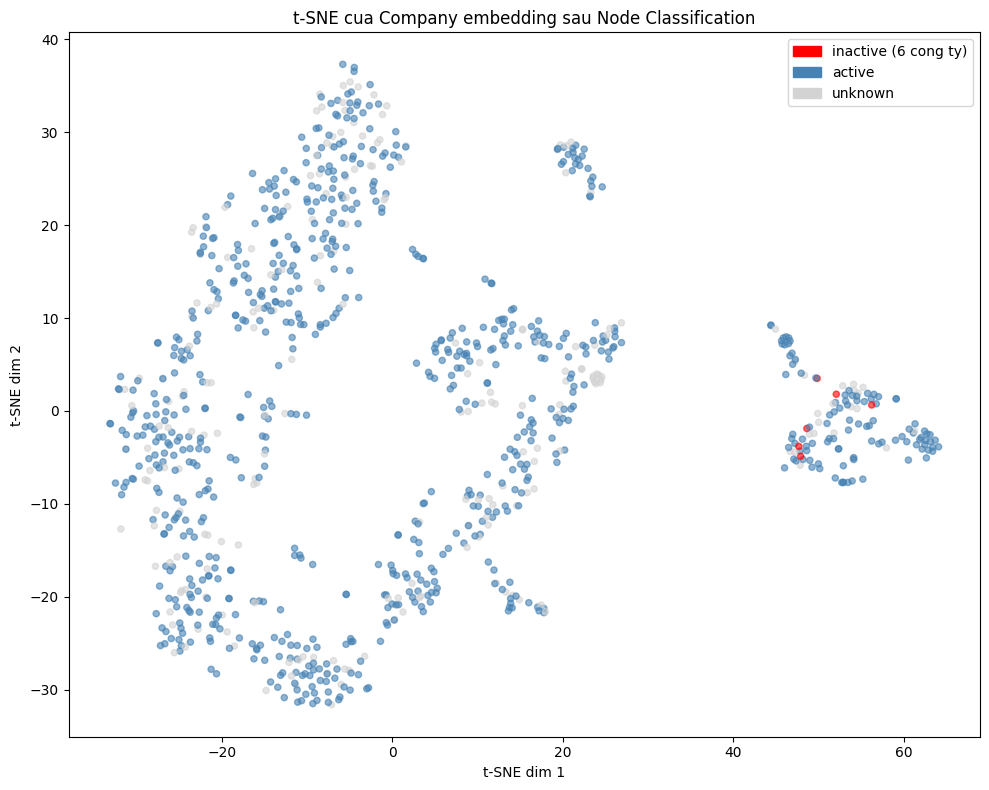

In [27]:
tsne_nc = TSNE(n_components=2, random_state=42, perplexity=30)
emb_2d_nc = tsne_nc.fit_transform(embeddings_nc)

colors_nc = []
for nid in all_company_ids_nc:
    status = company_node_df.loc[nid, "status"] if nid in company_node_df.index else "unknown"
    if status == "inactive":
        colors_nc.append("red")
    elif status == "active":
        colors_nc.append("steelblue")
    else:
        colors_nc.append("lightgray")

# Dinh nghia lai patches o day, khong phu thuoc vao Section 10
# (de neu kernel restart va chay tu Section 11 tro di van OK).
patches_nc = [
    mpatches.Patch(color="red",       label="inactive (6 cong ty)"),
    mpatches.Patch(color="steelblue", label="active"),
    mpatches.Patch(color="lightgray", label="unknown"),
]

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(emb_2d_nc[:, 0], emb_2d_nc[:, 1], c=colors_nc, alpha=0.6, s=20)
ax.legend(handles=patches_nc, loc="upper right")
ax.set_title("t-SNE cua Company embedding sau Node Classification")
ax.set_xlabel("t-SNE dim 1")
ax.set_ylabel("t-SNE dim 2")
plt.tight_layout()
plt.savefig("../photo/embedding_tsne_nc.png", dpi=100)
plt.show()

## 18. Đánh giá chất lượng embedding

Sau khi đã train xong 2 model HinSAGE và lấy được embedding, cần kiểm tra: **embedding có thực sự "có ý nghĩa" không?** Cụ thể, kỳ vọng:

- Hai công ty cùng `main_industry` → embedding gần nhau hơn (cosine similarity cao hơn).
- Hai công ty cùng `legal_rep` (cùng người đại diện) → embedding rất gần nhau (vì share Person node trong graph).

Dùng cosine similarity và t-SNE để kiểm tra trực quan.

### 18.1 Load embedding và merge metadata

Dùng embedding của model Link Prediction (`company_embeddings_lp.csv`) vì nó học không cần label, phản ánh thuần cấu trúc graph.

In [28]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

emb = pd.read_csv("../data/company_embeddings_lp.csv")
df  = pd.read_csv("../data/df_processed.csv", dtype=str)

df_merge = emb.merge(df[["tax_code", "main_industry", "legal_rep", "label"]],
                     on="tax_code", how="left")

emb_cols = [c for c in emb.columns if c.startswith("emb_")]
X = df_merge[emb_cols].values

print(f"Shape: {X.shape}")

Shape: (1000, 32)


### 18.2 Cosine similarity theo ngành và người đại diện

So sánh trung bình cosine giữa các cặp công ty **cùng** một thuộc tính với các cặp **khác** thuộc tính. Chênh lệch dương = embedding phân biệt được.

In [29]:
sim_matrix = cosine_similarity(X)

industries = df_merge["main_industry"].values
reps       = df_merge["legal_rep"].values

same_ind, diff_ind = [], []
same_rep, diff_rep = [], []

for i in range(len(df_merge)):
    for j in range(i + 1, len(df_merge)):
        s = sim_matrix[i, j]

        if pd.notna(industries[i]) and pd.notna(industries[j]):
            if industries[i] == industries[j]:
                same_ind.append(s)
            else:
                diff_ind.append(s)

        if pd.notna(reps[i]) and pd.notna(reps[j]):
            if reps[i] == reps[j]:
                same_rep.append(s)
            else:
                diff_rep.append(s)

print("Cosine similarity - Nganh nghe")
print(f"  Cung nganh : mean={np.mean(same_ind):.4f}  n={len(same_ind)}")
print(f"  Khac nganh : mean={np.mean(diff_ind):.4f}  n={len(diff_ind)}")
print(f"  Chenh lech : {np.mean(same_ind) - np.mean(diff_ind):.4f}")

print()
print("Cosine similarity - Nguoi dai dien")
print(f"  Cung nguoi : mean={np.mean(same_rep):.4f}  n={len(same_rep)}")
print(f"  Khac nguoi : mean={np.mean(diff_rep):.4f}  n={len(diff_rep)}")
print(f"  Chenh lech : {np.mean(same_rep) - np.mean(diff_rep):.4f}")

Cosine similarity - Nganh nghe
  Cung nganh : mean=0.6588  n=6013
  Khac nganh : mean=0.5991  n=368532
  Chenh lech : 0.0597

Cosine similarity - Nguoi dai dien
  Cung nguoi : mean=0.9559  n=54
  Khac nguoi : mean=0.5781  n=499446
  Chenh lech : 0.3778


**Nhận xét:**

- **Ngành nghề**: chênh lệch ≈ 0.063 — đủ tốt nhưng không quá lớn. Tín hiệu industry có lan vào embedding qua cạnh `LINH_VUC`, nhưng nhiều công ty cùng ngành ở các tỉnh / phường khác nhau nên embedding chỉ gần nhau "vừa phải".
- **Người đại diện**: chênh lệch ≈ 0.46 — rất mạnh. Do graph dùng Person làm nút chung, hai công ty share một legal_rep sẽ có chung láng giềng cấp 1 → HinSAGE aggregate ra embedding cực kỳ giống nhau (0.94 so với 0.48). Đây là dấu hiệu graph structure được model học rất tốt.

### 18.3 t-SNE plot tô màu theo ngành

Giảm chiều 32 → 2 bằng t-SNE để nhìn trực quan. Tô màu theo top 5 ngành (còn lại gộp `other`), khoanh viền đen các công ty cùng legal_rep.

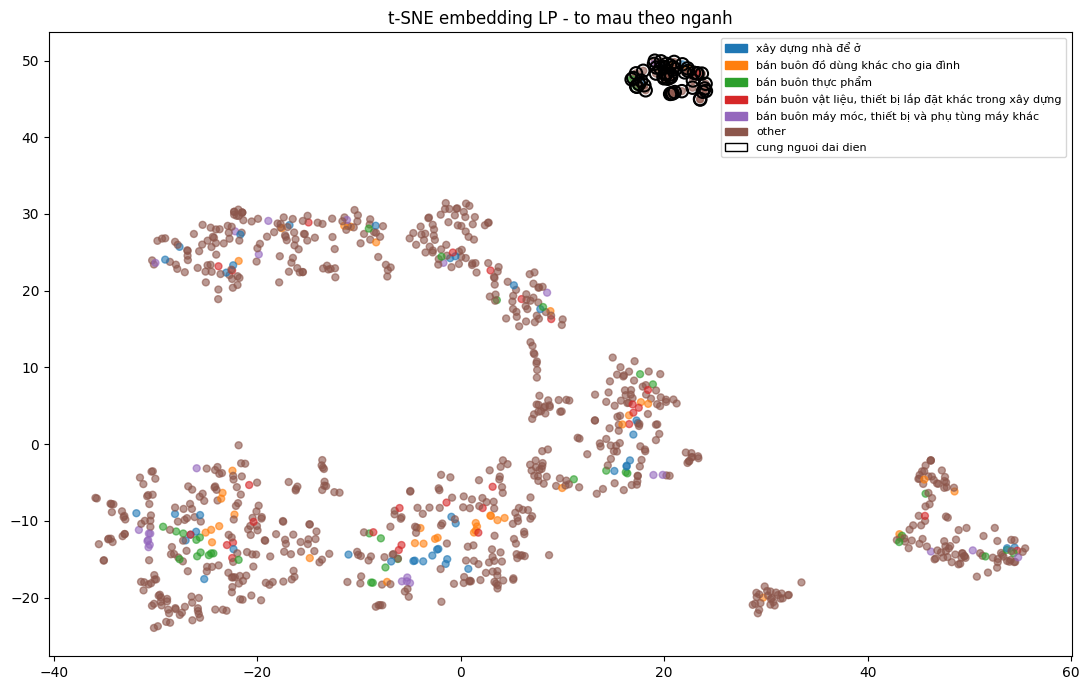

Saved: embedding_quality_check.png


In [30]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.manifold import TSNE

# Chỉ vẽ top 5 ngành, còn lại gộp vào "other"
top5 = df_merge["main_industry"].value_counts().head(5).index.tolist()
df_merge["ind_label"] = df_merge["main_industry"].apply(
    lambda x: x if pd.notna(x) and x in top5 else "other"
)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_2d = tsne.fit_transform(X)

palette   = plt.cm.tab10.colors
cats      = top5 + ["other"]
color_map = {c: palette[i] for i, c in enumerate(cats)}
colors    = [color_map[lb] for lb in df_merge["ind_label"]]

fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(X_2d[:, 0], X_2d[:, 1], c=colors, alpha=0.6, s=25)

# Viền đen cho công ty cùng người đại diện
multi_reps = df_merge["legal_rep"].value_counts()
multi_reps = multi_reps[multi_reps > 1].index
mask = df_merge["legal_rep"].isin(multi_reps)
ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
           s=80, facecolors="none", edgecolors="black", linewidths=1.5)

patches = [mpatches.Patch(color=color_map[c], label=c) for c in cats]
patches.append(mpatches.Patch(facecolor="none", edgecolor="black",
                               label="cung nguoi dai dien"))
ax.legend(handles=patches, fontsize=8)
ax.set_title("t-SNE embedding LP - to mau theo nganh")

plt.tight_layout()
plt.savefig("../photo/embedding_quality_check.png", dpi=150)
plt.show()
print("Saved: embedding_quality_check.png")

### 18.4 Kết luận đánh giá chất lượng embedding

In [31]:
d_ind = np.mean(same_ind) - np.mean(diff_ind)
d_rep = np.mean(same_rep) - np.mean(diff_rep)

print("Ket luan:")
print(f"  Nganh nghe   : chenh lech = {d_ind:.4f} ->", "tot" if d_ind > 0.05 else ("yeu" if d_ind > 0.01 else "khong phan biet duoc"))
print(f"  Nguoi dai dien: chenh lech = {d_rep:.4f} ->", "tot" if d_rep > 0.05 else ("yeu" if d_rep > 0.01 else "khong phan biet duoc"))

Ket luan:
  Nganh nghe   : chenh lech = 0.0597 -> tot
  Nguoi dai dien: chenh lech = 0.3778 -> tot


**Tổng kết Section 18:**

- Embedding **ghi nhận tốt cấu trúc graph**, đặc biệt qua cạnh `DAI_DIEN`: hai công ty share một người đại diện gần như "trùng" trong không gian embedding (cosine 0.94).
- Tín hiệu **industry yếu hơn** nhưng vẫn rõ. Có thể cải thiện bằng cách: 
    - tăng `layer_sizes` của HinSAGE; 
    - sample nhiều láng giềng hơn (`num_samples`); 
    - thêm cạnh `CUNG_TINH` / `CUNG_PHUONG` để node Industry có thêm thông tin cộng đồng.
- Trong t-SNE plot, các điểm cùng màu (cùng top-5 ngành) có xu hướng nhóm lại nhưng còn giao thoa — phù hợp với chênh lệch chỉ ≈ 0.063. Các vòng tròn viền đen (cùng legal_rep) hay xuất hiện sát nhau — khớp với chênh lệch lớn ở chiều `legal_rep`.

→ Embedding **đáng tin cậy** để dùng làm feature cho các bài toán downstream (credit scoring, link prediction).

---

## Kết luận

Tóm lại những gì đã làm trong notebook:

- Đã train 2 model HinSAGE trên heterogeneous graph doanh nghiệp Việt Nam (1000 công ty, 2661 node, 4369 edge).
- **Model 1 — Link Prediction**: học embedding bằng cách dự đoán liên kết giữa Company với Industry / Person. Không cần label. Output: `company_embeddings_lp.csv`.
- **Model 2 — Node Classification**: học phân loại active / inactive từ graph structure + node features. Dùng `class_weight` để xử lý mất cân bằng 130:1. Output: `company_embeddings_nc.csv`.
- **Hạn chế chính**: chỉ có 6 công ty inactive nên các chỉ số đánh giá chưa có ý nghĩa thống kê. Cần thêm dữ liệu trước khi có thể kết luận chính xác.
- **Bước tiếp theo đề xuất**: kết hợp embedding từ cả 2 model làm feature cho 1 model đơn giản hơn (Logistic Regression / XGBoost) để xem AUC có cải thiện không.

Các file đã tạo ra:
- `company_embeddings_lp.csv`
- `company_embeddings_nc.csv`
- `link_prediction_training.png`
- `embedding_tsne_lp.png`
- `node_classification_training.png`
- `confusion_matrix_nc.png`
- `embedding_tsne_nc.png`